<a href="https://colab.research.google.com/github/datafreak-adi/practice_ignore/blob/origin/Knn(Task_56).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` Train a KNN model on glass type dataset and find best n_neighnours.

Data Link: https://drive.google.com/file/d/17cbDNBmys04MJqQfrma3jd72VPMnxIq0/view?usp=share_link

In [18]:
# Your code goes here
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [19]:
glass= pd.read_csv('glass.csv')
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [20]:
glass.drop_duplicates(inplace=True)

In [21]:
# Splitting data and scaling it

from sklearn.model_selection import train_test_split

X= glass.iloc[:, :-1]
Y= glass.iloc[:, -1]


X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=20)

scaler= MinMaxScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [22]:
# Applying knn

def knn(X_train, Y_train, X_test, neighbors):

  knn= KNeighborsClassifier(n_neighbors=neighbors)
  knn.fit(X_train, Y_train)
  y_pred= knn.predict(X_test)


  return y_pred


In [23]:
from sklearn.metrics import accuracy_score

accur_score=[]

k_values= [i for i in range(1,16)]

for k in k_values:

  y_pred= knn(X_train,Y_train,X_test,k)
  accur= accuracy_score(Y_test, y_pred)
  accur_score.append(accur)


accur_score

[0.6511627906976745,
 0.627906976744186,
 0.6744186046511628,
 0.6511627906976745,
 0.5813953488372093,
 0.6511627906976745,
 0.627906976744186,
 0.6511627906976745,
 0.5581395348837209,
 0.627906976744186,
 0.6046511627906976,
 0.6046511627906976,
 0.5348837209302325,
 0.6046511627906976,
 0.5813953488372093]

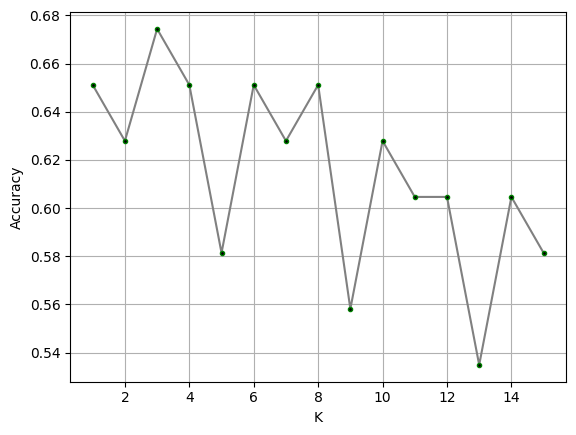

In [30]:
plt.plot(k_values,accur_score,c="grey",marker=".",mfc="black",mec="green")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()